In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import spateo as st
import scanpy as sc

2025-02-18 15:58:45.755731: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
/root/miniforge3/envs/spateo/lib/python3.8/site-packages/geopandas/_compat.py:124: UserWarning: The Shapely GEOS version (3.11.4-CAPI-1.17.4) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


fastpd is not installed. If you need mesh correction, please compile the fastpd library.


In [2]:
adata = sc.read_h5ad('/data/work/05.cluster/FuseMap/0106/Hippocampus_latent_embeddings_all_single_pretrain/dmt_leiden_20250108_1.h5ad')
adata.obs_names_make_unique()
adata

/root/miniforge3/envs/spateo/lib/python3.8/site-packages/anndata/_core/anndata.py:1838: UserWarning:

Observation names are not unique. To make them unique, call `.obs_names_make_unique`.



AnnData object with n_obs × n_vars = 1112773 × 33326
    obs: 'dnbCount', 'area', 'orig.ident', 'x', 'y', 'region', 'n_counts', 'region_h2', 'Tangram_1119_celltype', 'Tangram_1119_celltype_main_frac', 'region_hip', 'slice_code', 'sub_region', 'dmt_leiden', 'dmt_leiden_merge', 'dmt_leiden_anno'
    uns: 'dmt_leiden_colors', 'dmt_nn', 'leiden', 'slice_code_colors'
    obsm: 'X_dmt', 'X_dmt_highdim', 'align_spatial_2d', 'align_spatial_3d', 'cell_border', 'latent_embeddings_all_single_pretrain', 'latent_embeddings_all_spatial_pretrain', 'spatial', 'spatial_division'
    obsp: 'dmt_nn_connectivities', 'dmt_nn_distances'

In [15]:
dic_dmt_leiden = {
    '0': 'hip_sc_01',
    '7': 'hip_sc_02',
    
    '1': 'hip_sc_03',
    '3': 'hip_sc_04',
    '6': 'hip_sc_04',
    '14': 'hip_sc_05',
    
    
    '2': 'hip_sc_06',
    '13': 'hip_sc_07',
    '19': 'hip_sc_08',
    '20': 'hip_sc_09',
    
    '4': 'hip_sc_10',
    '21': 'hip_sc_10',
    
    '8': 'hip_sc_11',
    '10': 'hip_sc_12',
    '22': 'hip_sc_13',
    
    '9': 'hip_sc_14',
    '11': 'hip_sc_14',
    '16': 'hip_sc_15',
    '18': 'hip_sc_15',
    '26': 'hip_sc_15',
    '31': 'hip_sc_15',
    
    '12': 'hip_sc_16',
    '15': 'hip_sc_17',
    '25': 'hip_sc_17',
    '29': 'hip_sc_17',
    '17': 'hip_sc_18',
    
    '24': 'z_delete',
    
    
    '5': 'hip_sc_19',
    '23': 'hip_sc_20',
    '27': 'hip_sc_21',
    '28': 'hip_sc_22',
    '30': 'hip_sc_23',
}
adata.obs['dmt_leiden_anno'] = [dic_dmt_leiden[i] for i in adata.obs['dmt_leiden']]


In [16]:
adata = adata[adata.obs['dmt_leiden_anno'] != 'z_delete'].copy()

In [17]:
set(adata.obs['slice_code'])

{'12_B03605F3G5_WT202403310048.h5ad',
 '13_B03612A1C3_WT202403310056.h5ad',
 '14_A03591A1C3_WT202403310045.h5ad',
 '16_A03592A4C6_WT202403310044.h5ad',
 '18_B03602C4D6_WT202405020031.h5ad',
 '20_B03606F3G5_WT202405020032.h5ad',
 '22_B03606C4E6_WT202403310050.h5ad',
 '23_B03609A4D6_WT202404150263.h5ad',
 '27_B03610C1E3_WT202403310051.h5ad',
 '31_B03619A1D3_WT202403310052.h5ad',
 '35_B03619E4G6_WT202403310053.h5ad',
 '39_A03589A1D4_WT202403310046.h5ad',
 '43_A03590E1G4_WT202403310064.h5ad',
 '47_A03593C1F3_WT202403310068.h5ad',
 'B03607C4E6_WT2024071214941.h5ad'}

In [18]:
adata.uns['__type'] = 'UMI'

In [19]:
colormap = {'hip_sc_01': '#9b38e9',
            'hip_sc_02': '#a89630',
 'hip_sc_03': '#5b798b',
 'hip_sc_04': '#cb2505',
 'hip_sc_05': '#62e7dd',
 'hip_sc_06': '#245200',
 'hip_sc_07': '#374898',
 'hip_sc_08': '#6d85c7',
 'hip_sc_09': '#35c498',
 'hip_sc_10': '#9e2dc6',
 'hip_sc_11': '#2d7476',
 'hip_sc_12': '#cb0d6c',
 'hip_sc_13': '#20ea38',
 'hip_sc_14': '#0fabb6',
 'hip_sc_15': '#a59099',
 'hip_sc_16': '#2bea3a',
 'hip_sc_17': '#17b064',
 'hip_sc_18': '#52b8d5',
            'hip_sc_19': '#da2ef2',
 'hip_sc_20': '#6240f7',
 'hip_sc_21': '#c47233',
 'hip_sc_22': '#a83b23',
 'hip_sc_23': '#9994da',}

In [20]:
adata1 = adata[adata.obs['slice_code'] == 'B03607C4E6_WT2024071214941.h5ad'].copy()
adata2 = adata[adata.obs['slice_code'] == '43_A03590E1G4_WT202403310064.h5ad'].copy()

In [21]:
_, adata1 = st.tl.neighbors(
    adata1,
    basis='spatial',
    spatial_key='spatial',
    n_neighbors=20
)

|-----> <insert> spatial_distances to obsp in AnnData Object.
|-----> <insert> spatial_connectivities to obsp in AnnData Object.
|-----> <insert> spatial_neighbors to uns in AnnData Object.
|-----> <insert> spatial_neighbors.indices to uns in AnnData Object.
|-----> <insert> spatial_neighbors.params to uns in AnnData Object.


In [22]:
_, adata2 = st.tl.neighbors(
    adata2,
    basis='spatial',
    spatial_key='spatial',
    n_neighbors=20
)

|-----> <insert> spatial_distances to obsp in AnnData Object.
|-----> <insert> spatial_connectivities to obsp in AnnData Object.
|-----> <insert> spatial_neighbors to uns in AnnData Object.
|-----> <insert> spatial_neighbors.indices to uns in AnnData Object.
|-----> <insert> spatial_neighbors.params to uns in AnnData Object.


In [23]:
st.pl.plot_connections?

Signature:
st.pl.plot_connections(
    adata: anndata._core.anndata.AnnData,
    cat_key: str,
    spatial_key: str = 'spatial',
    n_spatial_neighbors: Union[NoneType, int] = 6,
    spatial_weights_matrix: Union[NoneType, scipy.sparse._csr.csr_matrix, numpy.ndarray] = None,
    expr_weights_matrix: Union[NoneType, scipy.sparse._csr.csr_matrix, numpy.ndarray] = None,
    reverse_expr_plot_orientation: bool = True,
    ax: Union[NoneType, matplotlib.axes._axes.Axes] = None,
    figsize: tuple = (3, 3),
    zero_self_connections: bool = True,
    normalize_by_self_connections: bool = False,
    shapes_style: bool = True,
    label_outline: bool = False,
    max_scale: float = 0.46,
    colormap: Union[str, dict, ForwardRef('mpl.colormap')] = 'Spectral',
    title_str: Union[NoneType, str] = None,
    title_fontsize: Union[NoneType, float] = None,
    label_fontsize: Union[NoneType, float] = None,
    save_show_or_return: Literal['save', 'show', 'return', 'both', 'all'] = 'show',
    sav

In [24]:
st.pl.plot_connections(
    adata1,
    cat_key='dmt_leiden_anno',
    # save_show_or_return='show',
    spatial_weights_matrix = adata1.obsp['spatial_connectivities'],
    title_str=" ",
    title_fontsize=6,
    label_fontsize=6,
    # colormap=adata.uns['color_key'],
    figsize=(4, 4),
    save_show_or_return = 'save',
    save_kwargs = {'path': '/data/work/05.cluster/FuseMap/0116/B03607C4E6_WT2024071214941.pdf'},
    colormap = colormap,
)


|-----> Filtering out cell types with fewer than 30 cells...
|-----> 
--- 23 labels, 31467 samples ---
initialized (24,) index ptr: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
initialized (31467,) indices: [0 0 0 ... 0 0 0]
initialized (31467,) data: [1 1 1 ... 1 1 1]

|-----> Deep copying AnnData object and working on the new copy. Original AnnData object will not be modified.
|-----> Matrix multiplying labels x weights x labels-transpose, shape (23, 31467) x (31467, 31467) x (31467, 23).
Saving figure to /data/work/05.cluster/FuseMap/0116/spatial_connections_B03607C4E6_WT2024071214941.pdf.pdf...
Done


In [ ]:
st.pl.plot_connections(
    adata2,
    cat_key='dmt_leiden_anno',
    # save_show_or_return='show',
    spatial_weights_matrix = adata1.obsp['spatial_connectivities'],
    title_str=" ",
    title_fontsize=6,
    label_fontsize=6,
    # colormap=adata.uns['color_key'],
    figsize=(4, 4),
    save_show_or_return = 'save',
    save_kwargs = {'path': '/data/work/05.cluster/FuseMap/0116/43_A03590E1G4_WT202403310064.pdf'},
    colormap = colormap,
)


|-----> Filtering out cell types with fewer than 30 cells...


In [12]:
colormap.keys()

dict_keys(['hip_sc_1', 'hip_sc_2', 'hip_sc_3', 'hip_sc_4', 'hip_sc_5', 'hip_sc_6', 'hip_sc_7', 'hip_sc_8', 'hip_sc_9', 'hip_sc_10', 'hip_sc_11', 'hip_sc_12', 'hip_sc_13', 'hip_sc_14', 'hip_sc_15', 'hip_sc_16', 'hip_sc_17', 'hip_sc_18', 'hip_sc_19', 'hip_sc_20', 'hip_sc_21', 'hip_sc_22', 'hip_sc_23'])

In [13]:
a = ['hip_sc_1', 'hip_sc_2', 'hip_sc_3', 'hip_sc_4', 'hip_sc_5', 'hip_sc_6', 'hip_sc_7', 'hip_sc_8', 'hip_sc_9', 'hip_sc_10', 
     'hip_sc_11', 'hip_sc_12', 'hip_sc_13', 'hip_sc_14', 'hip_sc_15', 'hip_sc_16', 'hip_sc_17', 'hip_sc_18', 'hip_sc_19', 'hip_sc_20', 
     'hip_sc_21', 'hip_sc_22', 'hip_sc_23']
df = pd.DataFrame({
    "celltype_sender": np.repeat(a, len(a)),
    "celltype_receiver": list(a)*len(a),
})
df = df[df['celltype_sender'] != df['celltype_receiver']]
df["celltype_pair"] = df["celltype_sender"].str.cat(
    df["celltype_receiver"], sep="-")
df = df.reset_index(drop=True)
df

,celltype_sender,celltype_receiver,celltype_pair
0,hip_sc_1,hip_sc_2,hip_sc_1-hip_sc_2
1,hip_sc_1,hip_sc_3,hip_sc_1-hip_sc_3
2,hip_sc_1,hip_sc_4,hip_sc_1-hip_sc_4
3,hip_sc_1,hip_sc_5,hip_sc_1-hip_sc_5
4,hip_sc_1,hip_sc_6,hip_sc_1-hip_sc_6
...,...,...,...
501,hip_sc_23,hip_sc_18,hip_sc_23-hip_sc_18
502,hip_sc_23,hip_sc_19,hip_sc_23-hip_sc_19
503,hip_sc_23,hip_sc_20,hip_sc_23-hip_sc_20
504,hip_sc_23,hip_sc_21,hip_sc_23-hip_sc_21


In [15]:
db_dir = '/data/work/05.cluster/FuseMap/0116/db/'

In [17]:
adata1.obs['dmt_leiden_anno'] =adata1.obs['dmt_leiden_anno'].astype('category')

In [ ]:
res = {}
# For pairs with no L:R interactions:
dropped = []
for idx, i in enumerate(df['celltype_pair']):
    s, r = i.split(sep='-')
    result = st.tl.find_cci_two_group(adata1,
                                      path=db_dir,
                                      species='human',
                                      group='dmt_leiden_anno',
                                      sender_group=s,
                                      receiver_group=r,
                                      filter_lr='outer',
                                      min_pairs=0,
                                      min_pairs_ratio=0,
                                      top=20,)
    if result is not None:
        res[i] = result
    else:
        dropped.append(idx)

result = pd.DataFrame(columns=res[df['celltype_pair'][1]]['lr_pair'].columns)
for l in df.index:
    if l not in dropped:
        res[df['celltype_pair'][l]]['lr_pair'] = res[df['celltype_pair'][l]
                                                     ]['lr_pair'].sort_values('lr_co_exp_ratio', ascending=False)[0:3]
        result = pd.concat([result, res[df['celltype_pair'][l]]
                           ['lr_pair']], axis=0, join='outer')

df_result = result.loc[result['lr_co_exp_num'] > 5]
df_result.drop_duplicates(
    subset=['lr_pair', 'sr_pair', ], keep='first', inplace=True)

/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo/tools/cci_two_cluster.py:244: RuntimeWarning:

invalid value encountered in divide

/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo/tools/cci_two_cluster.py:245: ImplicitModificationWarning:

Trying to modify attribute `.var` of view, initializing view as actual.

/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo/tools/cci_two_cluster.py:244: RuntimeWarning:

invalid value encountered in divide

/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo/tools/cci_two_cluster.py:244: RuntimeWarning:

invalid value encountered in divide

/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo/tools/cci_two_cluster.py:244: RuntimeWarning:

invalid value encountered in divide

/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo/tools/cci_two_cluster.py:244: RuntimeWarning:

invalid value encountered in divide

/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo

|-----> 20 ligands for cell type hip_sc_1_prox with highest fraction of prevalence: ['XCL2', 'BMP15', 'PLG', 'FGF10', 'IL36G', 'CCL17', 'COL6A5', 'FGF7', 'SELL', 'RAET1G', 'CCL5', 'CCL3', 'IHH', 'NTS', 'AVP', 'CORT', 'CCL25', 'TGFB2', 'TGFA', 'FGF3']. Testing interactions involving these genes.


/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo/tools/cci_two_cluster.py:244: RuntimeWarning:

invalid value encountered in divide

/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo/tools/cci_two_cluster.py:244: RuntimeWarning:

invalid value encountered in divide

/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo/tools/cci_two_cluster.py:244: RuntimeWarning:

invalid value encountered in divide

/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo/tools/cci_two_cluster.py:244: RuntimeWarning:

invalid value encountered in divide

/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo/tools/cci_two_cluster.py:244: RuntimeWarning:

invalid value encountered in divide

/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo/tools/cci_two_cluster.py:244: RuntimeWarning:

invalid value encountered in divide

/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo/tools/cci_two_cluster.py:244: RuntimeWarning:

i

|-----> 20 receptors for cell type hip_sc_2_prox with highest fraction of prevalence: ['ITGB7', 'C5AR1', 'GP1BA', 'CSF3R', 'EPHA1', 'KLRC1', 'EDAR', 'CCR9', 'CD8A', 'CHRNA1', 'RXFP2', 'KIR2DL1', 'TNFRSF13B', 'KLRK1', 'CCR6', 'IL18R1', 'LILRB2', 'MAG', 'ACKR4', 'CFC1']. Testing interactions involving these genes.


/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo/tools/cci_two_cluster.py:268: RuntimeWarning:

invalid value encountered in divide

/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo/tools/cci_two_cluster.py:268: RuntimeWarning:

invalid value encountered in divide

100%|██████████| 1000/1000 [00:39<00:00, 25.19it/s]
/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo/tools/cci_two_cluster.py:244: RuntimeWarning:

invalid value encountered in divide

/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo/tools/cci_two_cluster.py:245: ImplicitModificationWarning:

Trying to modify attribute `.var` of view, initializing view as actual.

/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo/tools/cci_two_cluster.py:244: RuntimeWarning:

invalid value encountered in divide

/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo/tools/cci_two_cluster.py:244: RuntimeWarning:

invalid value encountered in divide

/root/minif

...

/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo/tools/cci_two_cluster.py:268: RuntimeWarning:

invalid value encountered in divide

/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo/tools/cci_two_cluster.py:268: RuntimeWarning:

invalid value encountered in divide

100%|██████████| 1000/1000 [00:33<00:00, 30.02it/s]
/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo/tools/cci_two_cluster.py:244: RuntimeWarning:

invalid value encountered in divide

/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo/tools/cci_two_cluster.py:245: ImplicitModificationWarning:

Trying to modify attribute `.var` of view, initializing view as actual.

/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo/tools/cci_two_cluster.py:244: RuntimeWarning:

invalid value encountered in divide

/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo/tools/cci_two_cluster.py:244: RuntimeWarning:

invalid value encountered in divide

/root/minif

|-----> 20 ligands for cell type hip_sc_11_prox with highest fraction of prevalence: ['FGF19', 'EBI3', 'TNFSF14', 'CXCL8', 'RLN1', 'CD209', 'FGF3', 'GDNF', 'CXCL13', 'BMP2', 'WNT3A', 'HLA-G', 'GDF5', 'OCLN', 'BMP8B', 'CCL4', 'FGF18', 'SST', 'NPNT', 'AMH']. Testing interactions involving these genes.


/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo/tools/cci_two_cluster.py:244: RuntimeWarning:

invalid value encountered in divide

/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo/tools/cci_two_cluster.py:244: RuntimeWarning:

invalid value encountered in divide

/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo/tools/cci_two_cluster.py:244: RuntimeWarning:

invalid value encountered in divide

/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo/tools/cci_two_cluster.py:244: RuntimeWarning:

invalid value encountered in divide

/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo/tools/cci_two_cluster.py:244: RuntimeWarning:

invalid value encountered in divide

/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo/tools/cci_two_cluster.py:244: RuntimeWarning:

invalid value encountered in divide

/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo/tools/cci_two_cluster.py:244: RuntimeWarning:

i

|-----> 20 receptors for cell type hip_sc_19_prox with highest fraction of prevalence: ['ITGAX', 'TNFRSF10A', 'CHRNG', 'CSF3R', 'MRC1', 'CXCR5', 'DSG1', 'EPHA2', 'FLT3', 'CD40', 'TNFRSF11A', 'CCR10', 'NPFFR1', 'IL21R', 'IL17RE', 'FPR3', 'IL10RA', 'SCTR', 'CHRNE', 'GPR37L1']. Testing interactions involving these genes.


/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo/tools/cci_two_cluster.py:268: RuntimeWarning:

invalid value encountered in divide

/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo/tools/cci_two_cluster.py:268: RuntimeWarning:

invalid value encountered in divide

/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo/tools/cci_two_cluster.py:268: RuntimeWarning:

invalid value encountered in divide

/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo/tools/cci_two_cluster.py:268: RuntimeWarning:

invalid value encountered in divide

/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo/tools/cci_two_cluster.py:268: RuntimeWarning:

invalid value encountered in divide

 51%|█████▏    | 514/1000 [00:17<00:16, 29.63it/s]

In [ ]:
df_result

In [ ]:
1

In [11]:
sender_ct = 'hip_0_1'
receptor_ct = 'hip_0_2'

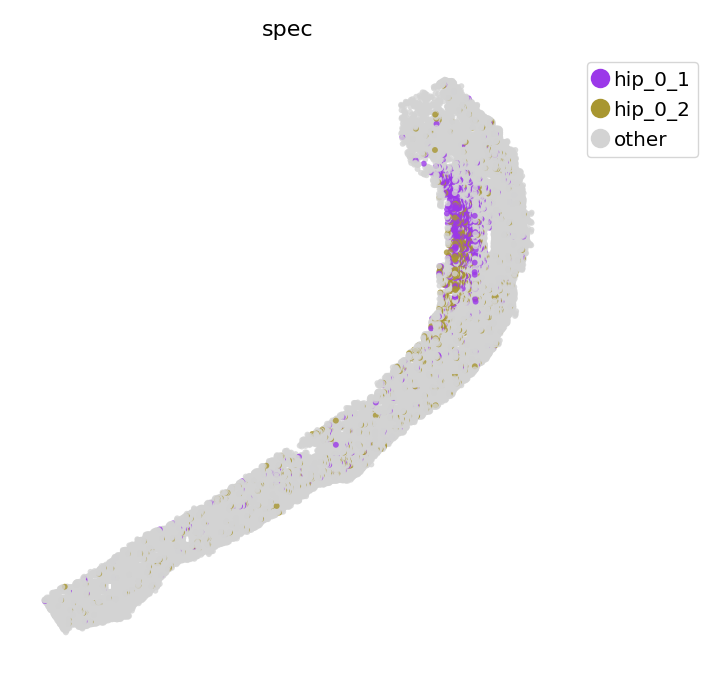

In [12]:
st.tl.prepare_cci_cellpair_adata(adata1, sender_group=sender_ct,
                                 receiver_group=receptor_ct, group='dmt_leiden_anno', all_cell_pair=True)
# plot all cell pair
st.pl.space(adata1,
            color=['spec'],
            pointsize=0.2,
            color_key={'other': '#D3D3D3', sender_ct: colormap
                       [sender_ct], receptor_ct: colormap[receptor_ct]},
            show_legend='upper left',
            figsize=(4, 4),
            save_show_or_return='show',
            #save_kwargs={"prefix": "./figures/left_2DPI_uninjury_cci_" + sender_ct + "_" + receptor_ct + "_all_cell_pair"}
            )

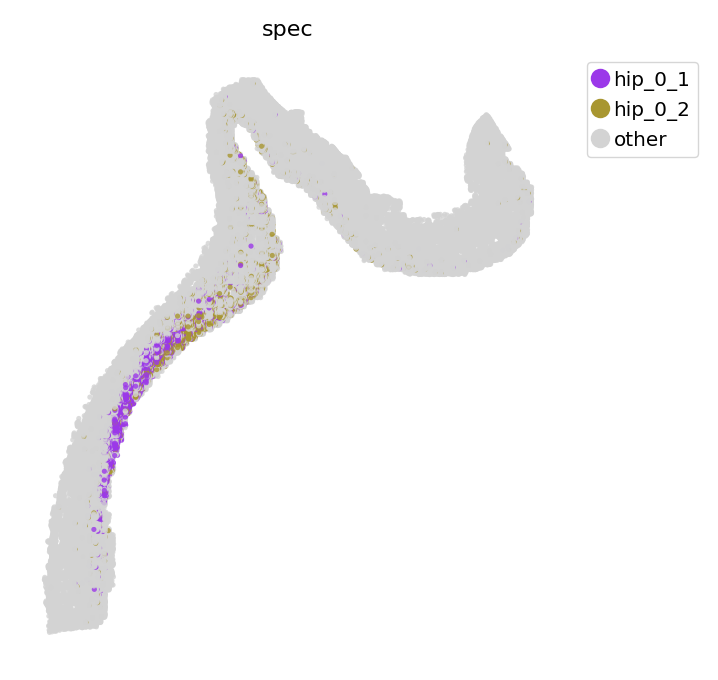

In [13]:
st.tl.prepare_cci_cellpair_adata(adata2, sender_group=sender_ct,
                                 receiver_group=receptor_ct, group='dmt_leiden_anno', all_cell_pair=True)
# plot all cell pair
st.pl.space(adata2,
            color=['spec'],
            pointsize=0.2,
            color_key={'other': '#D3D3D3', sender_ct: colormap
                       [sender_ct], receptor_ct: colormap[receptor_ct]},
            show_legend='upper left',
            figsize=(4, 4),
            save_show_or_return='show',
            #save_kwargs={"prefix": "./figures/left_2DPI_uninjury_cci_" + sender_ct + "_" + receptor_ct + "_all_cell_pair"}
            )

In [14]:
adata1.obs['dmt_leiden_anno'] = adata1.obs['dmt_leiden_anno'].astype('category')

In [15]:
res = st.tl.find_cci_two_group(adata1,
                               path='/data/work/05.cluster/FuseMap/0116/db/',
                               species='human',
                               group='dmt_leiden_anno',
                               sender_group=sender_ct,
                               receiver_group=receptor_ct,
                               filter_lr='outer',
                               min_pairs=0,
                               min_pairs_ratio=0,
                               top=20,)

/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo/tools/cci_two_cluster.py:244: RuntimeWarning:

invalid value encountered in divide

/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo/tools/cci_two_cluster.py:245: ImplicitModificationWarning:

Trying to modify attribute `.var` of view, initializing view as actual.

/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo/tools/cci_two_cluster.py:244: RuntimeWarning:

invalid value encountered in divide

/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo/tools/cci_two_cluster.py:244: RuntimeWarning:

invalid value encountered in divide

/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo/tools/cci_two_cluster.py:244: RuntimeWarning:

invalid value encountered in divide

/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo/tools/cci_two_cluster.py:244: RuntimeWarning:

invalid value encountered in divide

/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo

|-----> 20 ligands for cell type hip_0_1_prox with highest fraction of prevalence: ['XCL2', 'BMP15', 'PLG', 'FGF10', 'IL36G', 'CCL17', 'COL6A5', 'FGF7', 'SELL', 'RAET1G', 'CCL5', 'CCL3', 'IHH', 'NTS', 'AVP', 'CORT', 'CCL25', 'TGFB2', 'TGFA', 'FGF3']. Testing interactions involving these genes.


/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo/tools/cci_two_cluster.py:244: RuntimeWarning:

invalid value encountered in divide

/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo/tools/cci_two_cluster.py:244: RuntimeWarning:

invalid value encountered in divide

/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo/tools/cci_two_cluster.py:244: RuntimeWarning:

invalid value encountered in divide

/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo/tools/cci_two_cluster.py:244: RuntimeWarning:

invalid value encountered in divide

/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo/tools/cci_two_cluster.py:244: RuntimeWarning:

invalid value encountered in divide

/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo/tools/cci_two_cluster.py:244: RuntimeWarning:

invalid value encountered in divide

/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo/tools/cci_two_cluster.py:244: RuntimeWarning:

i

|-----> 20 receptors for cell type hip_0_2_prox with highest fraction of prevalence: ['KIR2DL1', 'CCR9', 'ACKR4', 'CSF3R', 'ITGB7', 'KLRC1', 'CHRNA1', 'MAG', 'CFC1', 'GP1BA', 'CCR6', 'C5AR1', 'EDAR', 'RXFP2', 'TNFRSF13B', 'IL18R1', 'IL1RL2', 'CD8A', 'KLRK1', 'LILRB2']. Testing interactions involving these genes.


/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo/tools/cci_two_cluster.py:268: RuntimeWarning:

invalid value encountered in divide

/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo/tools/cci_two_cluster.py:268: RuntimeWarning:

invalid value encountered in divide

/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo/tools/cci_two_cluster.py:268: RuntimeWarning:

invalid value encountered in divide

/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo/tools/cci_two_cluster.py:268: RuntimeWarning:

invalid value encountered in divide

/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo/tools/cci_two_cluster.py:268: RuntimeWarning:

invalid value encountered in divide

/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo/tools/cci_two_cluster.py:268: RuntimeWarning:

invalid value encountered in divide

/root/miniforge3/envs/spateo/lib/python3.8/site-packages/spateo/tools/cci_two_cluster.py:268: RuntimeWarning:

i

(None, [<Axes: title={'center': 'spec'}>])

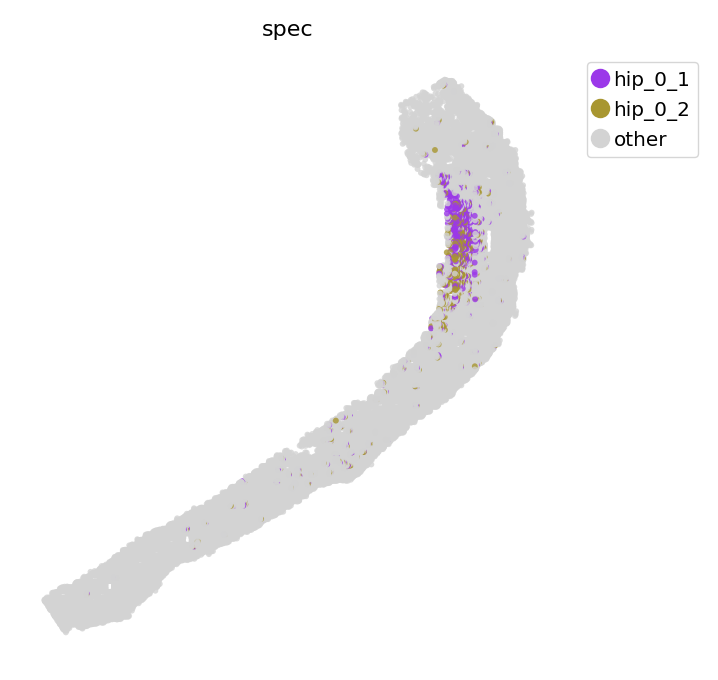

In [18]:
st.tl.prepare_cci_cellpair_adata(
    adata1, sender_group=sender_ct, receiver_group=receptor_ct, cci_dict=res, all_cell_pair=False)
# plot
st.pl.space(adata1,
            color=['spec'],
            pointsize=0.2,
            color_key={'other': '#D3D3D3', sender_ct: colormap
                       [sender_ct], receptor_ct: colormap[receptor_ct]},
            show_legend='upper left',
            figsize=(4, 4),
            save_show_or_return='return',
            #save_kwargs={"prefix": "./figures/left_2DPI_uninjury_cci_" + sender_ct + "_" + receptor_ct + "_cell_pair"}
            )

In [19]:
df = res['lr_pair']
df = df.loc[df['lr_co_exp_num'] > 0].sort_values(
    'lr_co_exp_ratio', ascending=False)[0:10]

In [20]:
df

,from,to,pathway,type,lr_pair,lr_product,lr_co_exp_num,lr_co_exp_ratio,lr_co_exp_ratio_pvalue,is_significant,sr_pair
2185,NTS,NTSR1,NTS,Secreted Signaling,NTS-NTSR1,0.012955,11,0.003852,0.000,True,hip_0_1-hip_0_2
16,TGFB2,ACVR1B,TGFb,Secreted Signaling,TGFB2-ACVR1B,0.001751,3,0.001050,0.002,True,hip_0_1-hip_0_2
3687,HLA-E,CD8A,MHC-I,Cell-Cell Contact,HLA-E-CD8A,0.001401,2,0.000700,0.000,True,hip_0_1-hip_0_2
4,TGFB2,TGFBR1,TGFb,Secreted Signaling,TGFB2-TGFBR1,0.001050,1,0.000350,0.315,False,hip_0_1-hip_0_2
5,TGFB2,TGFBR2,TGFb,Secreted Signaling,TGFB2-TGFBR2,0.001050,1,0.000350,0.076,False,hip_0_1-hip_0_2
1458,TGFA,ERBB2,EGF,Secreted Signaling,TGFA-ERBB2,0.000350,1,0.000350,0.034,True,hip_0_1-hip_0_2
2207,CORT,SSTR1,SEMATOSTATIN,Secreted Signaling,CORT-SSTR1,0.002101,1,0.000350,0.001,True,hip_0_1-hip_0_2
3814,SELL,PODXL,SELL,Cell-Cell Contact,SELL-PODXL,0.000700,1,0.000350,0.003,True,hip_0_1-hip_0_2


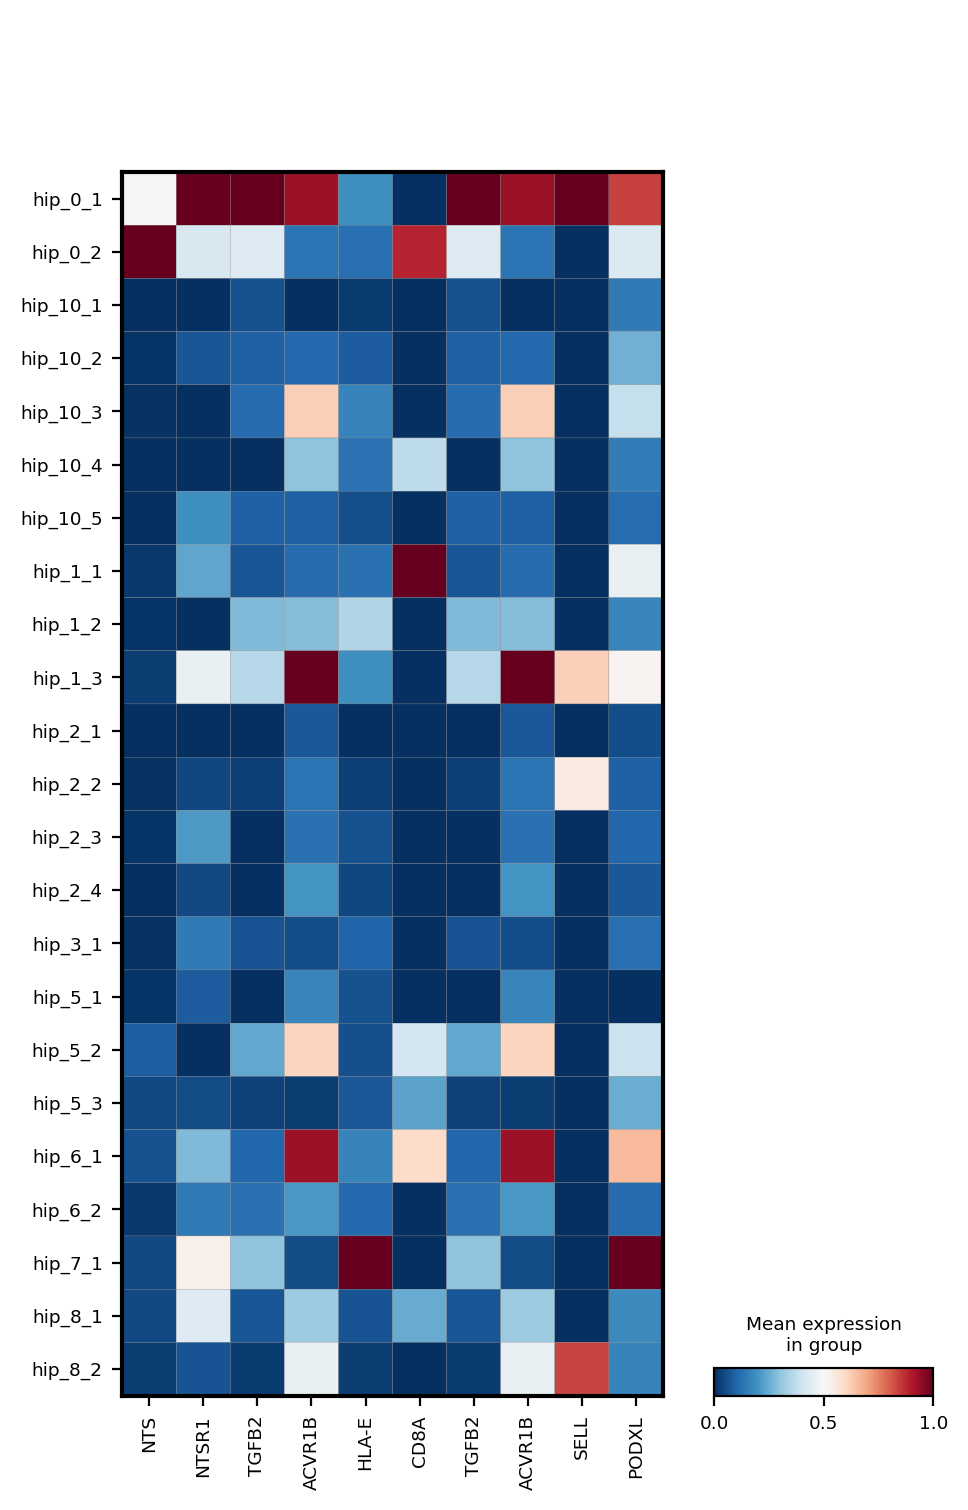

In [29]:
sc.pl.matrixplot(adata1, ['NTS', 'NTSR1','TGFB2','ACVR1B','HLA-E', 'CD8A', 'TGFB2', 'ACVR1B', 'SELL', 'PODXL'], 'dmt_leiden_anno', standard_scale = 'var',)

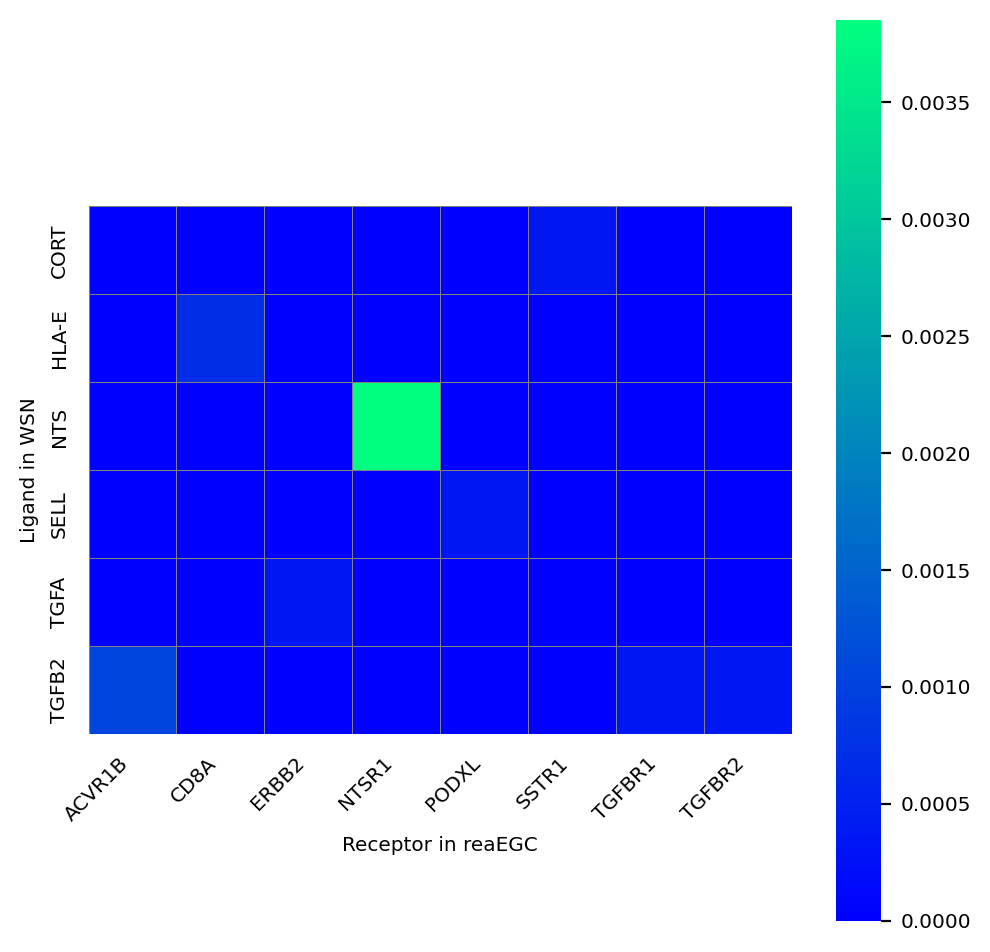

In [30]:
%matplotlib inline
data1 = df
test = data1.pivot(index="from", columns="to",
                   values="lr_co_exp_ratio").fillna(0)
fig = plt.figure()
fig.set_size_inches(5, 5)
x_label = list(test.columns.tolist())
y_label = list(test.index)
ax = sns.heatmap(test,
                 cmap="winter",
                 square=True,
                 yticklabels=y_label,
                 linecolor='grey',
                 linewidths=0.3,
                 annot_kws={'size': 10, 'weight': 'bold', },
                 xticklabels=x_label,
                 #mask=(test < 0.01)
                )
plt.gcf().subplots_adjust(bottom=0.3)
plt.xlabel("Receptor in reaEGC")
plt.ylabel("Ligand in WSN")
ax.set_xticklabels(x_label, rotation=45, ha="right")
ax.xaxis.set_ticks_position('none')
ax.yaxis.set_ticks_position('none')
plt.tight_layout()
#plt.savefig("./figures/2DPI_sub_cci_WSN_ReaEGC_heatmap.pdf", transparent=True)